<a href="https://colab.research.google.com/github/vvrgit/ReinforcementLearningCourse/blob/main/GridWorldProblem_Stochastic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%writefile grid_env_stoc.py
def env_state():
  states=["S0","S1","S2","S3","S5","S6","S7","G"]
  return states

def env_actions():
  actions=["up","down","left","Right"]
  return actions

def env_reward():
  reward={
    "move":-0.5,
    "goal":100,
    "obs":-2
  }
  return reward

def env_df():
  gama=0.9
  return gama

def env_transition():
  transition={
      ("S0","Right"):[("S1",0.8),("S0",0.1),("S3",0.1)],
      ("S0","down"):[("S3",0.8),("S0",0.1),("S1",0.1)],
      ("S0","left"):[("S0",0.8),("S1",0.1),("S3",0.1)],
      ("S0","up"):[("S0",0.8),("S1",0.1),("S3",0.1)],
      ("S1","Right"):[("S2",0.7),("S1",0.2),("S3",0.1)],
      ("S1","down"):[("S1",0.8),("S0",0.1),("S2",0.1)],
      ("S1","left"):[("S0",0.7),("S1",0.2),("S2",0.1)],
      ("S1","up"):[("S1",0.8),("S0",0.1),("S2",0.1)],
      ("S2","Right"):[("S2",0.7),("S1",0.2),("S5",0.1)],
      ("S2","down"):[("S5",0.8),("S0",0.1),("S2",0.1)],
      ("S2","left"):[("S1",0.7),("S2",0.2),("S5",0.1)],
      ("S2","up"):[("S2",0.8),("S1",0.1),("S5",0.1)],
      ("S3","Right"):[("S3",0.7),("S0",0.2),("S6",0.1)],
      ("S3","down"):[("S6",0.8),("S3",0.1),("S0",0.1)],
      ("S3","left"):[("S3",0.7),("S0",0.2),("S6",0.1)],
      ("S3","up"):[("S0",0.8),("S1",0.1),("S6",0.1)],
      ("S5","Right"):[("S5",0.7),("S2",0.2),("G",0.1)],
      ("S5","down"):[("G",0.8),("S5",0.1),("S2",0.1)],
      ("S5","left"):[("S5",0.7),("G",0.2),("S0",0.1)],
      ("S5","up"):[("S2",0.8),("G",0.1),("S5",0.1)],
      ("S6","Right"):[("S7",0.7),("S3",0.2),("S6",0.1)],
      ("S6","down"):[("S6",0.8),("S3",0.1),("S7",0.1)],
      ("S6","left"):[("S6",0.7),("S3",0.2),("S7",0.1)],
      ("S6","up"):[("S3",0.8),("S7",0.1),("S6",0.1)],
      ("S7","Right"):[("G",0.7),("S7",0.2),("S6",0.1)],
      ("S7","down"):[("S7",0.8),("G",0.1),("S6",0.1)],
      ("S7","left"):[("S6",0.7),("G",0.2),("S7",0.1)],
      ("S7","up"):[("S7",0.8),("G",0.1),("S6",0.1)]
  }
  return transition


Overwriting grid_env_stoc.py


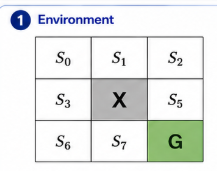

In [2]:
import grid_env_stoc as env


state=env.env_state()
print(state)
actions=env.env_actions()
print(actions)
reward=env.env_reward()
print(reward)
gama=env.env_df()
print(gama)
transition=env.env_transition()
print(transition)


['S0', 'S1', 'S2', 'S3', 'S5', 'S6', 'S7', 'G']
['up', 'down', 'left', 'Right']
{'move': -0.5, 'goal': 100, 'obs': -2}
0.9
{('S0', 'Right'): [('S1', 0.8), ('S0', 0.1), ('S3', 0.1)], ('S0', 'down'): [('S3', 0.8), ('S0', 0.1), ('S1', 0.1)], ('S0', 'left'): [('S0', 0.8), ('S1', 0.1), ('S3', 0.1)], ('S0', 'up'): [('S0', 0.8), ('S1', 0.1), ('S3', 0.1)], ('S1', 'Right'): [('S2', 0.7), ('S1', 0.2), ('S3', 0.1)], ('S1', 'down'): [('S1', 0.8), ('S0', 0.1), ('S2', 0.1)], ('S1', 'left'): [('S0', 0.7), ('S1', 0.2), ('S2', 0.1)], ('S1', 'up'): [('S1', 0.8), ('S0', 0.1), ('S2', 0.1)], ('S2', 'Right'): [('S2', 0.7), ('S1', 0.2), ('S5', 0.1)], ('S2', 'down'): [('S5', 0.8), ('S0', 0.1), ('S2', 0.1)], ('S2', 'left'): [('S1', 0.7), ('S2', 0.2), ('S5', 0.1)], ('S2', 'up'): [('S2', 0.8), ('S1', 0.1), ('S5', 0.1)], ('S3', 'Right'): [('S3', 0.7), ('S0', 0.2), ('S6', 0.1)], ('S3', 'down'): [('S6', 0.8), ('S3', 0.1), ('S0', 0.1)], ('S3', 'left'): [('S3', 0.7), ('S0', 0.2), ('S6', 0.1)], ('S3', 'up'): [('S0', 0

# **Random State selection based on probabilities**

In [3]:
import random

current_state="S0"
action=random.choice(env.env_actions())

# List of (state, probability)
all_trans = env.env_transition()
transitions = all_trans[(current_state, action)]
print(transitions)

# Separate states and probabilities
states = [state for state, prob in transitions]
probabilities = [prob for state, prob in transitions]
print(states)
print(probabilities)

# Randomly select one state based on probabilities
next_state = random.choices(states, weights=probabilities, k=1)[0]
print("Next State:", next_state)

[('S3', 0.8), ('S0', 0.1), ('S1', 0.1)]
['S3', 'S0', 'S1']
[0.8, 0.1, 0.1]
Next State: S3


# **Random Agent**

In [4]:
import grid_env_stoc as env
import random

state=env.env_state()
actions=env.env_actions()
reward=env.env_reward()
gama=env.env_df()
all_trans=env.env_transition()

current_state="S0"
total_reward=0

while current_state!="G":
  action=random.choice(actions)

  # List of (state, probability)
  transitions = all_trans[(current_state, action)]

  # Separate states and probabilities
  states = [state for state, prob in transitions]
  probabilities = [prob for state, prob in transitions]

  # Randomly select one state based on probabilities
  next_state = random.choices(states, weights=probabilities, k=1)[0]

  if(next_state==current_state):
    total_reward=total_reward+reward["obs"]
  elif(next_state=="G"):
    total_reward=total_reward+reward["goal"]
  else:
    total_reward=total_reward+reward["move"]

  print(f"current state: {current_state} \t action: {action} \t next state: {next_state} \t total_reward={total_reward}")
  current_state=next_state

print(f"total reward: {total_reward}")

current state: S0 	 action: up 	 next state: S3 	 total_reward=-0.5
current state: S3 	 action: up 	 next state: S0 	 total_reward=-1.0
current state: S0 	 action: Right 	 next state: S1 	 total_reward=-1.5
current state: S1 	 action: left 	 next state: S0 	 total_reward=-2.0
current state: S0 	 action: down 	 next state: S0 	 total_reward=-4.0
current state: S0 	 action: up 	 next state: S0 	 total_reward=-6.0
current state: S0 	 action: left 	 next state: S0 	 total_reward=-8.0
current state: S0 	 action: Right 	 next state: S1 	 total_reward=-8.5
current state: S1 	 action: left 	 next state: S1 	 total_reward=-10.5
current state: S1 	 action: up 	 next state: S0 	 total_reward=-11.0
current state: S0 	 action: left 	 next state: S0 	 total_reward=-13.0
current state: S0 	 action: Right 	 next state: S1 	 total_reward=-13.5
current state: S1 	 action: Right 	 next state: S3 	 total_reward=-14.0
current state: S3 	 action: up 	 next state: S0 	 total_reward=-14.5
current state: S0 	 